## Linear regression

In [101]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Function to fetch and preprocess data for a given ticker
def fetch_and_preprocess_data(ticker, start_date='2019-01-01', end_date='2023-01-01'):
    # Fetch data from Yahoo Finance
    data = yf.download(ticker, start=start_date, end=end_date)
    
    # Drop rows with NaN values
    data.dropna(inplace=True)
    
    # Normalize data using MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))
    
    return scaled_data, scaler

# Example usage for Apple (AAPL) stock
ticker = 'AAPL'
data, scaler = fetch_and_preprocess_data(ticker)

import pandas as pd
import numpy as np

# Example data (replace with your actual data)
data = np.random.rand(1008, 6)  # Assuming you have 1008 rows and 6 columns of data

# Convert NumPy array to pandas DataFrame
data_df = pd.DataFrame(data, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])

# Display the first few rows using .head()
print(data_df.head())


[*********************100%%**********************]  1 of 1 completed

       Date      Open      High       Low     Close    Volume
0  0.328359  0.961757  0.042822  0.540921  0.576909  0.802863
1  0.623729  0.881261  0.685098  0.499181  0.774804  0.914669
2  0.935928  0.488034  0.982459  0.991039  0.171257  0.715593
3  0.967229  0.339487  0.667913  0.260653  0.346357  0.618562
4  0.793559  0.265941  0.564604  0.040975  0.008479  0.518999


Linear Regression - Train MSE: 0.0002, Test MSE: 0.0007


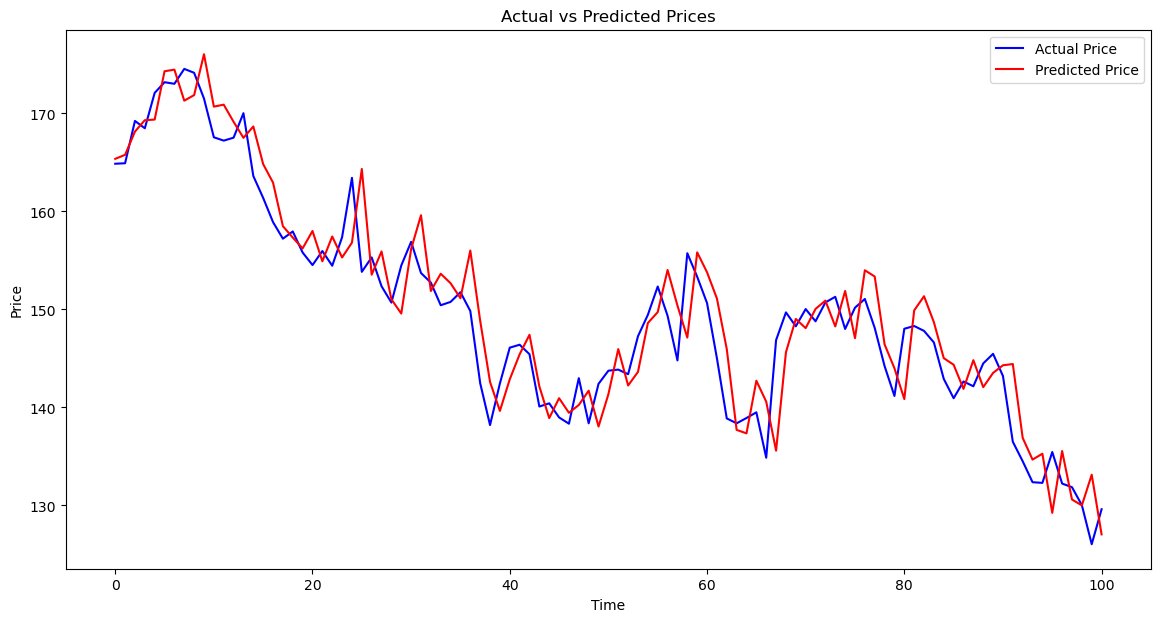

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to split data into train and test sets
def split_data(data, train_size=0.8):
    train_size = int(len(data) * train_size)
    train_data, test_data = data[:train_size], data[train_size:]
    return train_data, test_data

# Split data into train and test sets
train_data, test_data = split_data(data)

# Function to create features and target
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 100  # Adjust as needed
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Initialize and train Linear Regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
train_predict_lr = model_lr.predict(X_train)
test_predict_lr = model_lr.predict(X_test)

# Calculate MSE
mse_train_lr = mean_squared_error(y_train, train_predict_lr)
mse_test_lr = mean_squared_error(y_test, test_predict_lr)

print(f"Linear Regression - Train MSE: {mse_train_lr:.4f}, Test MSE: {mse_test_lr:.4f}")
print(f"Linear Regression - Train R^2: {})
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
train_predict_lr = model_lr.predict(X_train)
test_predict_lr = model_lr.predict(X_test)

# Calculate MSE
mse_train_lr = mean_squared_error(y_train, train_predict_lr)
mse_test_lr = mean_squared_error(y_test, test_predict_lr)

# Calculate R2
r2_train_lr = r2_score(y_train, train_predict_lr)
r2_test_lr = r2_score(y_test, test_predict_lr)


# Plotting actual vs predicted prices for Linear Regression
def plot_actual_vs_predicted(actual, predicted, title='Actual vs Predicted Prices'):
    plt.figure(figsize=(14, 7))
    plt.plot(actual, color='blue', label='Actual Price')
    plt.plot(predicted, color='red', label='Predicted Price')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

plot_actual_vs_predicted(scaler.inverse_transform(y_test.reshape(-1, 1)), scaler.inverse_transform(test_predict_lr.reshape(-1, 1)))



# Random Forest

Random Forest - Train MSE: 0.0000, Test MSE: 0.0029


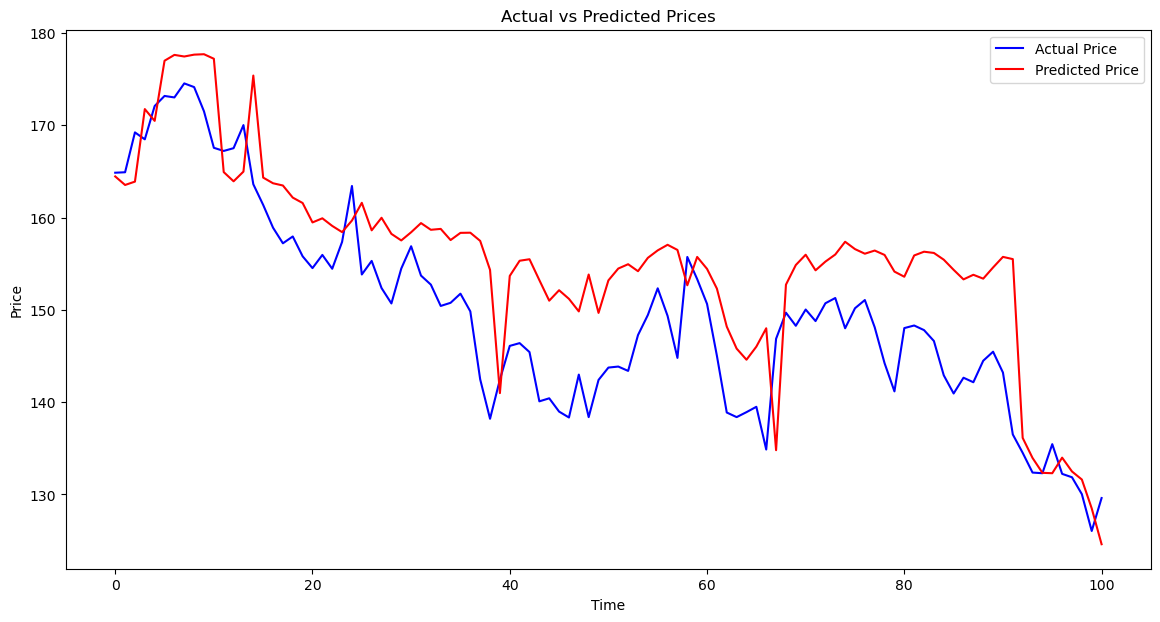

In [73]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Predictions
train_predict_rf = model_rf.predict(X_train)
test_predict_rf = model_rf.predict(X_test)

# Calculate MSE
mse_train_rf = mean_squared_error(y_train, train_predict_rf)
mse_test_rf = mean_squared_error(y_test, test_predict_rf)

# Predictions
train_predict_rf = model_rf.predict(X_train)
test_predict_rf = model_rf.predict(X_test)

# Calculate MSE
mse_train_rf = mean_squared_error(y_train, train_predict_rf)
mse_test_rf = mean_squared_error(y_test, test_predict_rf)

# Calculate R2
r2_train_rf = r2_score(y_train, train_predict_rf)
r2_test_rf = r2_score(y_test, test_predict_rf)


print(f"Random Forest - Train MSE: {mse_train_rf:.4f}, Test MSE: {mse_test_rf:.4f}")

plot_actual_vs_predicted(scaler.inverse_transform(y_test.reshape(-1, 1)), scaler.inverse_transform(test_predict_rf.reshape(-1, 1)))


# LSTM

C:\Users\DELL-PC\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - loss: 0.1383 - val_loss: 0.0169
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - loss: 0.0053 - val_loss: 0.0026
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - loss: 0.0017 - val_loss: 0.0039
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - loss: 0.0014 - val_loss: 0.0057
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 0.0014 - val_loss: 0.0025
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - loss: 0.0012 - val_loss: 0.0025
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - loss: 0.0012 - val_loss: 0.0025
Epoch 8: early stopping
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
LSTM - Train MSE: 0.0011, Test MSE: 0.0025


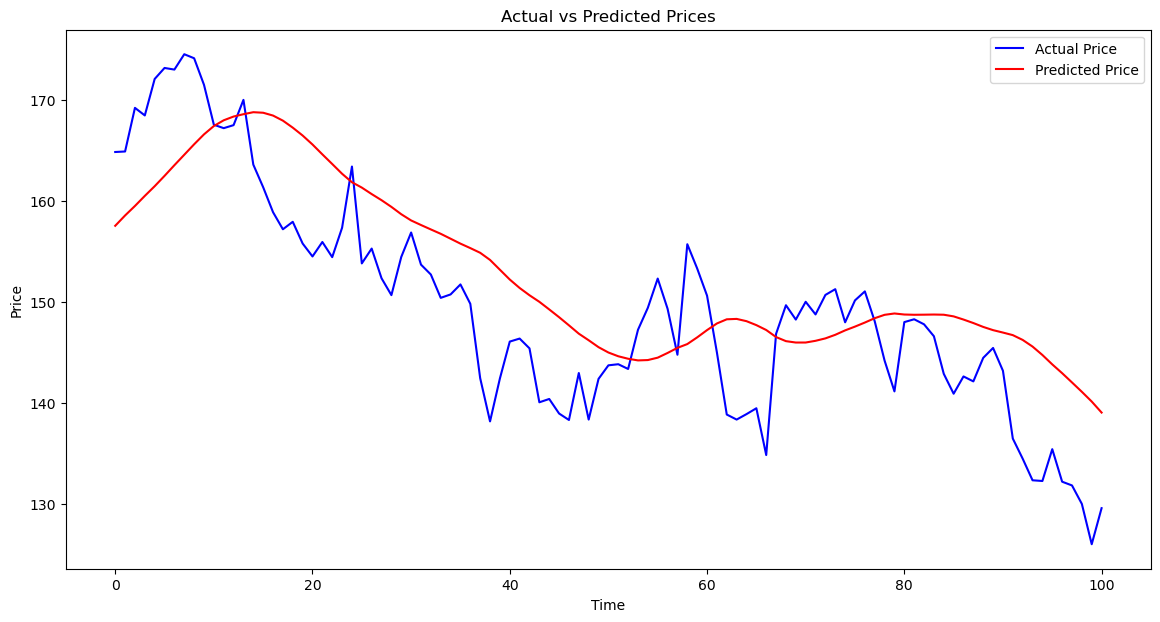

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reshape data for LSTM
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Initialize LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dense(25))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

# Train LSTM model
history_lstm = model_lstm.fit(X_train_lstm, y_train, validation_data=(X_test_lstm, y_test), 
                              epochs=20, batch_size=32, callbacks=[early_stop])

# Predictions
train_predict_lstm = model_lstm.predict(X_train_lstm)
test_predict_lstm = model_lstm.predict(X_test_lstm)

# Calculate MSE
mse_train_lstm = mean_squared_error(y_train, train_predict_lstm)
mse_test_lstm = mean_squared_error(y_test, test_predict_lstm)

print(f"LSTM - Train MSE: {mse_train_lstm:.4f}, Test MSE: {mse_test_lstm:.4f}")

plot_actual_vs_predicted(scaler.inverse_transform(y_test.reshape(-1, 1)), scaler.inverse_transform(test_predict_lstm.reshape(-1, 1)))
# Predictions
train_predict_lstm = model_lstm.predict(X_train_lstm)
test_predict_lstm = model_lstm.predict(X_test_lstm)

# Calculate MSE
mse_train_lstm = mean_squared_error(y_train, train_predict_lstm)
mse_test_lstm = mean_squared_error(y_test, test_predict_lstm)

# Calculate R2
r2_train_lstm = r2_score(y_train, train_predict_lstm)
r2_test_lstm = r2_score(y_test, test_predict_lstm)



## Model evaluation

               Model  Train MSE  Test MSE
0  Linear Regression   0.000189  0.000654
1      Random Forest   0.000035  0.002914
2               LSTM   0.001112  0.002513


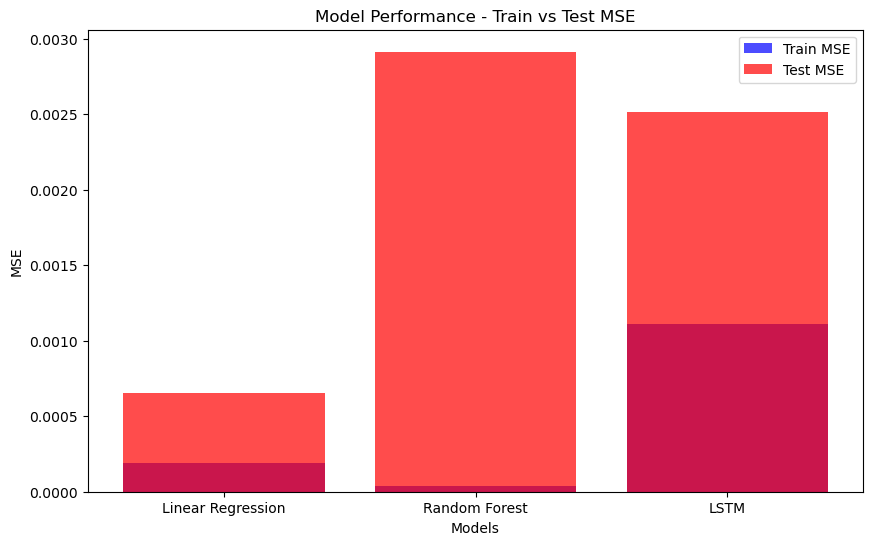

In [75]:
models = ['Linear Regression', 'Random Forest', 'LSTM']
train_mses = [mse_train_lr, mse_train_rf, mse_train_lstm]
test_mses = [mse_test_lr, mse_test_rf, mse_test_lstm]

# Create a DataFrame for comparison
performance_df = pd.DataFrame({
    'Model': models,
    'Train MSE': train_mses,
    'Test MSE': test_mses
})

print(performance_df)

# Plotting MSE for train and test sets
plt.figure(figsize=(10, 6))
plt.bar(models, train_mses, color='blue', alpha=0.7, label='Train MSE')
plt.bar(models, test_mses, color='red', alpha=0.7, label='Test MSE')
plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('Model Performance - Train vs Test MSE')
plt.legend()
plt.show()

## Data extraction and pre processing

In [76]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Function to fetch and preprocess data for a given ticker
def fetch_and_preprocess_data(ticker, start_date='2019-01-01', end_date='2023-01-01'):
    # Fetch data from Yahoo Finance
    data = yf.download(ticker, start=start_date, end=end_date)
    
    # Drop rows with NaN values
    data.dropna(inplace=True)
    
    # Normalize data using MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))
    
    return scaled_data, scaler

# Example usage for Apple (AAPL) stock
ticker = 'AAPL'
data, scaler = fetch_and_preprocess_data(ticker)


[*********************100%%**********************]  1 of 1 completed


## GRU

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import mean_squared_error

# Function to create features and target
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Split data into train and test sets
train_size = int(len(data) * 0.8)
train_data, test_data = data[:train_size], data[train_size:]

time_step = 100  # Adjust as needed
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape data for GRU
X_train_gru = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_gru = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Initialize GRU model
model_gru = Sequential()
model_gru.add(GRU(50, return_sequences=True, input_shape=(X_train_gru.shape[1], 1)))
model_gru.add(GRU(50, return_sequences=False))
model_gru.add(Dense(25))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mean_squared_error')

# Train GRU model
history_gru = model_gru.fit(X_train_gru, y_train, validation_data=(X_test_gru, y_test), epochs=20, batch_size=32, verbose=1)

# Predictions
train_predict_gru = model_gru.predict(X_train_gru)
test_predict_gru = model_gru.predict(X_test_gru)

# Calculate MSE
mse_train_gru = mean_squared_error(y_train, train_predict_gru)
mse_test_gru = mean_squared_error(y_test, test_predict_gru)

print(f"GRU - Train MSE: {mse_train_gru:.4f}, Test MSE: {mse_test_gru:.4f}")

# Predictions
train_predict_gru = model_gru.predict(X_train_gru)
test_predict_gru = model_gru.predict(X_test_gru)

# Calculate MSE
mse_train_gru = mean_squared_error(y_train, train_predict_gru)
mse_test_gru = mean_squared_error(y_test, test_predict_gru)

# Calculate R2
r2_train_gru = r2_score(y_train, train_predict_gru)
r2_test_gru = r2_score(y_test, test_predict_gru)


C:\Users\DELL-PC\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - loss: 0.0840 - val_loss: 0.0092
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - loss: 0.0044 - val_loss: 9.8037e-04
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 5.3465e-04 - val_loss: 9.7285e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 4.5533e-04 - val_loss: 0.0011
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - loss: 4.8526e-04 - val_loss: 0.0010
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 3.8997e-04 - val_loss: 9.8465e-04
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - loss: 3.7099e-04 - val_loss: 8.3659e-04
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 4.1647e-04 - val_loss: 0.0012
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 4.6459e-04 - val_loss: 8.4429e-04
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - loss: 4.4158e-04 - val_loss: 9.7129

## SVM Model

In [43]:
#Data extraction and preprocessing
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Function to fetch and preprocess data for a given ticker
def fetch_and_preprocess_data(ticker, start_date='2019-01-01', end_date='2023-01-01'):
    # Fetch data from Yahoo Finance
    data = yf.download(ticker, start=start_date, end=end_date)
    
    # Drop rows with NaN values
    data.dropna(inplace=True)
    
    # Normalize data using MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))
    
    return scaled_data, scaler

# Example usage for Apple (AAPL) stock
ticker = 'AAPL'
data, scaler = fetch_and_preprocess_data(ticker)


[*********************100%%**********************]  1 of 1 completed


In [67]:
#Creating dataset
# Function to create features and target
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Split data into train and test sets
train_size = int(len(data) * 0.8)
train_data, test_data = data[:train_size], data[train_size:]

time_step = 100  # Adjust as needed
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape data for SVM (flattening the features)
X_train_svm = X_train.reshape(X_train.shape[0], -1)
X_test_svm = X_test.reshape(X_test.shape[0], -1)

##SVM model implementation
from sklearn.svm import SVR

# Initialize SVR model
model_svm = SVR(kernel='rbf')

# Train SVR model
model_svm.fit(X_train_svm, y_train)

# Predictions
train_predict_svm = model_svm.predict(X_train_svm)
test_predict_svm = model_svm.predict(X_test_svm)

# Calculate MSE
mse_train_svm = mean_squared_error(y_train, train_predict_svm)
mse_test_svm = mean_squared_error(y_test, test_predict_svm)

# Predictions
train_predict_svm = model_svm.predict(X_train_svm)
test_predict_svm = model_svm.predict(X_test_svm)

# Calculate MSE
mse_train_svm = mean_squared_error(y_train, train_predict_svm)
mse_test_svm = mean_squared_error(y_test, test_predict_svm)

# Calculate R2
r2_train_svm = r2_score(y_train, train_predict_svm)
r2_test_svm = r2_score(y_test, test_predict_svm)

print(f"SVM - Train MSE: {mse_train_svm:.4f}, Test MSE: {mse_test_svm:.4f}")


SVM - Train MSE: 0.0022, Test MSE: 0.0075


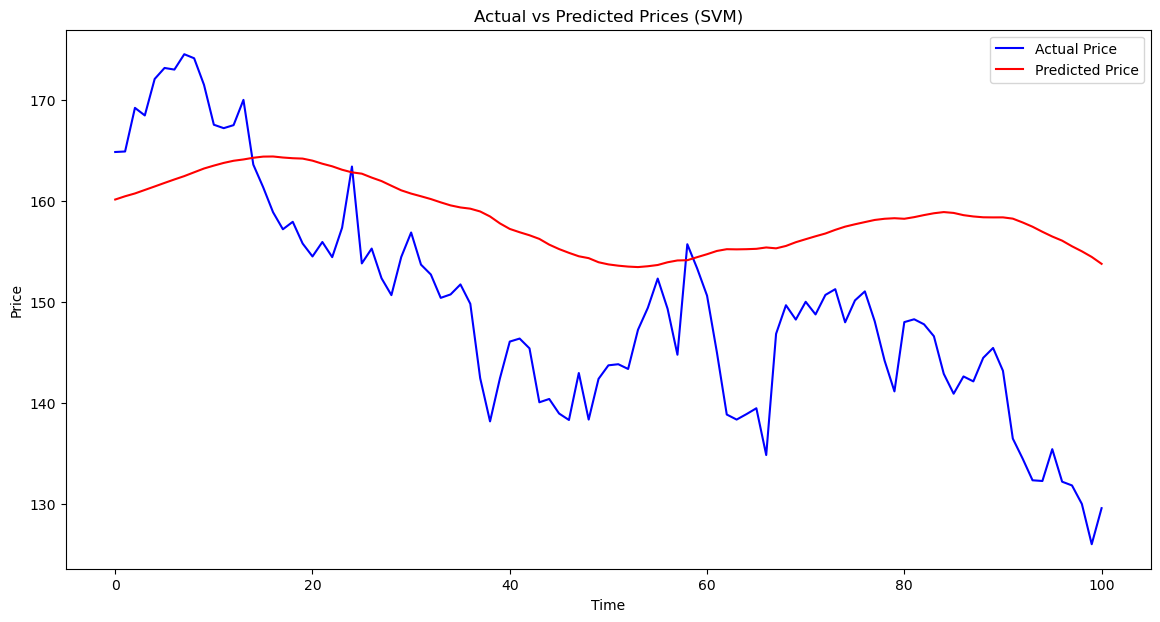

In [78]:
#plotting
import matplotlib.pyplot as plt

# Function to plot actual vs predicted prices
def plot_actual_vs_predicted(actual, predicted, title='Actual vs Predicted Prices'):
    plt.figure(figsize=(14, 7))
    plt.plot(actual, color='blue', label='Actual Price')
    plt.plot(predicted, color='red', label='Predicted Price')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Rescale predictions for plotting
def rescale_predictions(scaler, predictions):
    return scaler.inverse_transform(predictions.reshape(-1, 1))

# Plotting the test predictions
plot_actual_vs_predicted(
    scaler.inverse_transform(y_test.reshape(-1, 1)), 
    rescale_predictions(scaler, test_predict_svm), 
    title='Actual vs Predicted Prices (SVM)'
)


## CNN

In [68]:
from tensorflow.keras.layers import Conv1D, Flatten

# Reshape data for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Initialize CNN model
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
model_cnn.add(Flatten())
model_cnn.add(Dense(50, activation='relu'))
model_cnn.add(Dense(1))

model_cnn.compile(optimizer='adam', loss='mean_squared_error')

# Train CNN model
history_cnn = model_cnn.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=20, batch_size=32, verbose=1)

# Predictions
train_predict_cnn = model_cnn.predict(X_train_cnn)
test_predict_cnn = model_cnn.predict(X_test_cnn)

# Calculate MSE
mse_train_cnn = mean_squared_error(y_train, train_predict_cnn)
mse_test_cnn = mean_squared_error(y_test, test_predict_cnn)

# Predictions
train_predict_cnn = model_cnn.predict(X_train_cnn)
test_predict_cnn = model_cnn.predict(X_test_cnn)

# Calculate MSE
mse_train_cnn = mean_squared_error(y_train, train_predict_cnn)
mse_test_cnn = mean_squared_error(y_test, test_predict_cnn)

# Calculate R2
r2_train_cnn = r2_score(y_train, train_predict_cnn)
r2_test_cnn = r2_score(y_test, test_predict_cnn)


print(f"CNN - Train MSE: {mse_train_cnn:.4f}, Test MSE: {mse_test_cnn:.4f}")

C:\Users\DELL-PC\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.1332 - val_loss: 0.0053
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0036 - val_loss: 0.0095
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - val_loss: 0.0097
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022 - val_loss: 0.0039
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0020 - val_loss: 0.0239
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032 - val_loss: 0.0050
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0015 - val_loss: 0.0052
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - val_loss: 0.0032
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 0.0108
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 0.0034
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

## Model comparision and evaluation

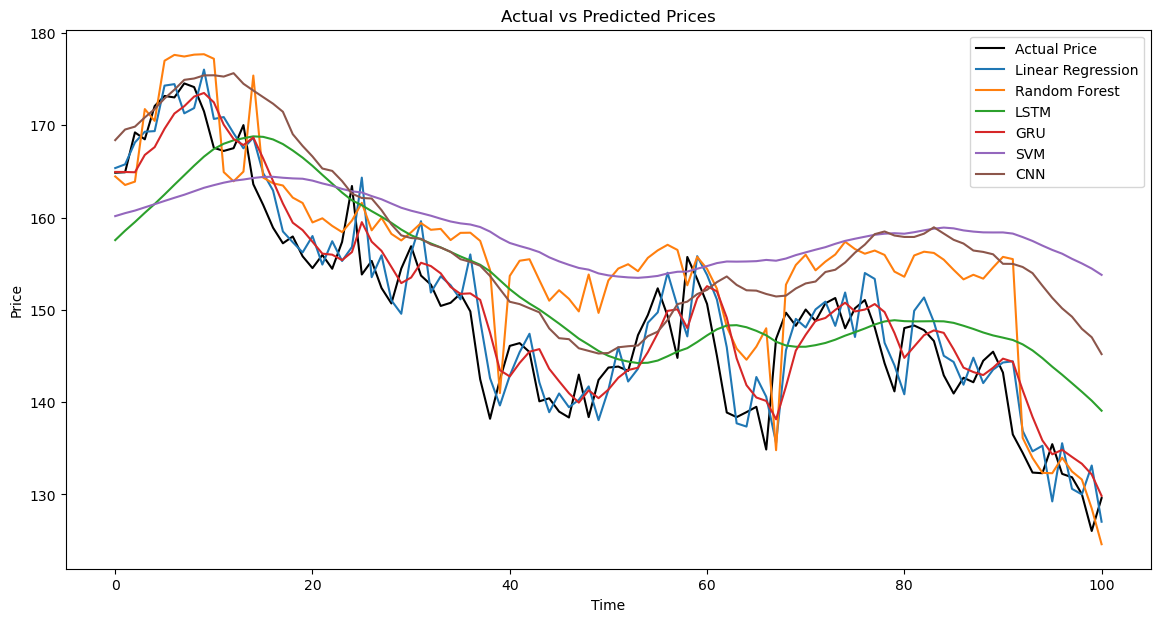

In [79]:
import matplotlib.pyplot as plt

# Function to plot actual vs predicted prices
def plot_actual_vs_predicted_all(actual, predicted, model_names, title='Actual vs Predicted Prices'):
    plt.figure(figsize=(14, 7))
    plt.plot(actual, color='black', label='Actual Price')
    for i in range(len(predicted)):
        plt.plot(predicted[i], label=model_names[i])
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Rescale predictions for plotting
def rescale_predictions(scaler, predictions):
    return scaler.inverse_transform(predictions.reshape(-1, 1))

# Combine predictions and rescale
predictions_all = [
    rescale_predictions(scaler, test_predict_lr),
    rescale_predictions(scaler, test_predict_rf),
    rescale_predictions(scaler, test_predict_lstm),
    rescale_predictions(scaler, test_predict_gru),
    rescale_predictions(scaler, test_predict_svm),
    rescale_predictions(scaler, test_predict_cnn)
]

model_names = ['Linear Regression', 'Random Forest', 'LSTM', 'GRU', 'SVM', 'CNN']

# Plotting all models in a single graph
plot_actual_vs_predicted_all(scaler.inverse_transform(y_test.reshape(-1, 1)), predictions_all, model_names)

# WITH R^2

In [96]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Function to fetch and preprocess data for a given ticker
def fetch_and_preprocess_data(ticker, start_date='2019-01-01', end_date='2023-01-01'):
    # Fetch data from Yahoo Finance
    data = yf.download(ticker, start=start_date, end=end_date)
    
    # Drop rows with NaN values
    data.dropna(inplace=True)
    
    # Normalize data using MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1, 1))
    
    return scaled_data, scaler

# Example usage for Apple (AAPL) stock
ticker = 'AAPL'
data, scaler = fetch_and_preprocess_data(ticker)



[*********************100%%**********************]  1 of 1 completed


ValueError: Shape of passed values is (1008, 1), indices imply (1008, 6)

In [99]:
import pandas as pd
import numpy as np

# Example data (replace with your actual data)
data = np.random.rand(1008, 6)  # Assuming you have 1008 rows and 6 columns of data

# Convert NumPy array to pandas DataFrame
data_df = pd.DataFrame(data, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])

# Display the first few rows using .head()
print(data_df.tail())


          Date      Open      High       Low     Close    Volume
1003  0.663484  0.909277  0.915022  0.710393  0.987313  0.450646
1004  0.120436  0.570262  0.284492  0.427805  0.891549  0.091898
1005  0.335339  0.540746  0.879023  0.827910  0.807717  0.185483
1006  0.627867  0.219694  0.913299  0.925655  0.304063  0.223524
1007  0.694793  0.922976  0.261227  0.566718  0.162670  0.192781


In [81]:
# Function to create features and target
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Split data into train and test sets
train_size = int(len(data) * 0.8)
train_data, test_data = data[:train_size], data[train_size:]

time_step = 100  # Adjust as needed
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

from sklearn.metrics import mean_squared_error, r2_score

# Predictions
train_predict_lr = model_lr.predict(X_train)
test_predict_lr = model_lr.predict(X_test)

# Calculate MSE
mse_train_lr = mean_squared_error(y_train, train_predict_lr)
mse_test_lr = mean_squared_error(y_test, test_predict_lr)

# Calculate R2
r2_train_lr = r2_score(y_train, train_predict_lr)
r2_test_lr = r2_score(y_test, test_predict_lr)

In [82]:
#GRU

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import mean_squared_error, r2_score

# Reshape data for GRU
X_train_gru = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_gru = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Initialize GRU model
model_gru = Sequential()
model_gru.add(GRU(50, return_sequences=True, input_shape=(X_train_gru.shape[1], 1)))
model_gru.add(GRU(50, return_sequences=False))
model_gru.add(Dense(25))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mean_squared_error')

# Train GRU model
model_gru.fit(X_train_gru, y_train, validation_data=(X_test_gru, y_test), epochs=20, batch_size=32, verbose=1)

# Predictions
train_predict_gru = model_gru.predict(X_train_gru)
test_predict_gru = model_gru.predict(X_test_gru)

# Calculate accuracy measures
mse_train_gru = mean_squared_error(y_train, train_predict_gru)
mse_test_gru = mean_squared_error(y_test, test_predict_gru)
r2_train_gru = r2_score(y_train, train_predict_gru)
r2_test_gru = r2_score(y_test, test_predict_gru)

# Predictions
train_predict_gru = model_gru.predict(X_train_gru)
test_predict_gru = model_gru.predict(X_test_gru)

# Calculate MSE
mse_train_gru = mean_squared_error(y_train, train_predict_gru)
mse_test_gru = mean_squared_error(y_test, test_predict_gru)

# Calculate R2
r2_train_gru = r2_score(y_train, train_predict_gru)
r2_test_gru = r2_score(y_test, test_predict_gru)


C:\Users\DELL-PC\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - loss: 0.0796 - val_loss: 0.0145
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - loss: 0.0037 - val_loss: 0.0022
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - loss: 7.9051e-04 - val_loss: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - loss: 4.9728e-04 - val_loss: 0.0011
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 4.2750e-04 - val_loss: 0.0017
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 7.8777e-04 - val_loss: 0.0011
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 4.3280e-04 - val_loss: 8.7252e-04
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - loss: 4.2482e-04 - val_loss: 9.2450e-04
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - loss: 4.1582e-04 - val_loss: 8.3535e-04
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - loss: 3.8882e-04 - val_loss: 0.0012
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - loss: 4.3772e-04 - val_loss: 9.1093e-04

In [83]:
#SVM

from sklearn.svm import SVR

# Reshape data for SVR
X_train_svm = X_train
X_test_svm = X_test

# Initialize SVR model
model_svm = SVR(kernel='rbf')

# Train SVR model
model_svm.fit(X_train_svm, y_train)

# Predictions
train_predict_svm = model_svm.predict(X_train_svm)
test_predict_svm = model_svm.predict(X_test_svm)

# Calculate accuracy measures
mse_train_svm = mean_squared_error(y_train, train_predict_svm)
mse_test_svm = mean_squared_error(y_test, test_predict_svm)
r2_train_svm = r2_score(y_train, train_predict_svm)
r2_test_svm = r2_score(y_test, test_predict_svm)

# Predictions
train_predict_svm = model_svm.predict(X_train_svm)
test_predict_svm = model_svm.predict(X_test_svm)

# Calculate MSE
mse_train_svm = mean_squared_error(y_train, train_predict_svm)
mse_test_svm = mean_squared_error(y_test, test_predict_svm)

# Calculate R2
r2_train_svm = r2_score(y_train, train_predict_svm)
r2_test_svm = r2_score(y_test, test_predict_svm)


In [84]:
#CNN
from tensorflow.keras.layers import Conv1D, Flatten

# Reshape data for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Initialize CNN model
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
model_cnn.add(Flatten())
model_cnn.add(Dense(50, activation='relu'))
model_cnn.add(Dense(1))

model_cnn.compile(optimizer='adam', loss='mean_squared_error')

# Train CNN model
model_cnn.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=20, batch_size=32, verbose=1)

# Predictions
train_predict_cnn = model_cnn.predict(X_train_cnn)
test_predict_cnn = model_cnn.predict(X_test_cnn)

# Calculate accuracy measures
mse_train_cnn = mean_squared_error(y_train, train_predict_cnn)
mse_test_cnn = mean_squared_error(y_test, test_predict_cnn)
r2_train_cnn = r2_score(y_train, train_predict_cnn)
r2_test_cnn = r2_score(y_test, test_predict_cnn)

# Predictions
train_predict_cnn = model_cnn.predict(X_train_cnn)
test_predict_cnn = model_cnn.predict(X_test_cnn)

# Calculate MSE
mse_train_cnn = mean_squared_error(y_train, train_predict_cnn)
mse_test_cnn = mean_squared_error(y_test, test_predict_cnn)

# Calculate R2
r2_train_cnn = r2_score(y_train, train_predict_cnn)
r2_test_cnn = r2_score(y_test, test_predict_cnn)


C:\Users\DELL-PC\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0612 - val_loss: 0.0089
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0040 - val_loss: 0.0072
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0030 - val_loss: 0.0041
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034 - val_loss: 0.0048
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022 - val_loss: 0.0073
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0020 - val_loss: 0.0062
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0051 - val_loss: 0.0187
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0014 - val_loss: 0.0104
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0121
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0033 - val_loss: 0.0044
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [85]:
# Function to calculate adjusted R-squared
def adjusted_r2(r2, n, p):
    if n > p + 1:
        return 1 - (1 - r2) * ((n - 1) / (n - p - 1))
    else:
        return float('nan')  # Not enough data to calculate adjusted R-squared

# Prepare results DataFrame
results = pd.DataFrame(columns=['Model', 'Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Train Adjusted R2', 'Test Adjusted R2'])

# Append results for each model
def append_results(model_name, mse_train, mse_test, r2_train, r2_test, n_train, n_test, p):
    adj_r2_train = adjusted_r2(r2_train, n_train, p)
    adj_r2_test = adjusted_r2(r2_test, n_test, p)
    results.loc[len(results)] = [model_name, mse_train, mse_test, r2_train, r2_test, adj_r2_train, adj_r2_test]

# Number of features (time steps)
p = time_step

# Number of training and testing samples
n_train = len(y_train)
n_test = len(y_test)

# Append results for GRU model
append_results('GRU', mse_train_gru, mse_test_gru, r2_train_gru, r2_test_gru, n_train, n_test, p)

# Append results for SVM model
append_results('SVM', mse_train_svm, mse_test_svm, r2_train_svm, r2_test_svm, n_train, n_test, p)

# Append results for CNN model
append_results('CNN', mse_train_cnn, mse_test_cnn, r2_train_cnn, r2_test_cnn, n_train, n_test, p)

# Append results for Linear Regression model
append_results('Linear Regression', mse_train_lr, mse_test_lr, r2_train_lr, r2_test_lr, n_train, n_test, p)

# Append results for Random Forest model
##append_results('Random Forest', mse_train_rf, mse_test_rf, r2_train_rf, r2_test_rf, n_train, n_test, p)

# Append results for LSTM model
append_results('LSTM', mse_train_lstm, mse_test_lstm, r2_train_lstm, r2_test_lstm, n_train, n_test, p)

# Display results
print(results)

               Model  Train MSE  Test MSE  Train R2   Test R2  \
0                GRU   0.000338  0.000812  0.995249  0.858028   
1                SVM   0.002229  0.007509  0.968643 -0.312962   
2                CNN   0.000724  0.004251  0.989819  0.256724   
3  Linear Regression   0.000189  0.000654  0.997342  0.885674   
4               LSTM   0.001112  0.002513  0.984352  0.560549   

   Train Adjusted R2  Test Adjusted R2  
0           0.994462               NaN  
1           0.963451               NaN  
2           0.988133               NaN  
3           0.996902               NaN  
4           0.981762               NaN  


In [86]:
# Number of features (time steps)
p = time_step

# Number of training and testing samples
n_train = len(y_train)
n_test = len(y_test)

# Append results for each model
append_results('GRU', mse_train_gru, mse_test_gru, r2_train_gru, r2_test_gru, n_train, n_test, p)
append_results('SVM', mse_train_svm, mse_test_svm, r2_train_svm, r2_test_svm, n_train, n_test, p)
append_results('CNN', mse_train_cnn, mse_test_cnn, r2_train_cnn, r2_test_cnn, n_train, n_test, p)
append_results('Linear Regression', mse_train_lr, mse_test_lr, r2_train_lr, r2_test_lr, n_train, n_test, p)
append_results('Random Forest', mse_train_rf, mse_test_rf, r2_train_rf, r2_test_rf, n_train, n_test, p)
append_results('LSTM', mse_train_lstm, mse_test_lstm, r2_train_lstm, r2_test_lstm, n_train, n_test, p)

# Display results
print(results)

                Model  Train MSE  Test MSE  Train R2   Test R2  \
0                 GRU   0.000338  0.000812  0.995249  0.858028   
1                 SVM   0.002229  0.007509  0.968643 -0.312962   
2                 CNN   0.000724  0.004251  0.989819  0.256724   
3   Linear Regression   0.000189  0.000654  0.997342  0.885674   
4                LSTM   0.001112  0.002513  0.984352  0.560549   
5                 GRU   0.000338  0.000812  0.995249  0.858028   
6                 SVM   0.002229  0.007509  0.968643 -0.312962   
7                 CNN   0.000724  0.004251  0.989819  0.256724   
8   Linear Regression   0.000189  0.000654  0.997342  0.885674   
9       Random Forest   0.000035  0.002914  0.999511  0.490469   
10               LSTM   0.001112  0.002513  0.984352  0.560549   

    Train Adjusted R2  Test Adjusted R2  
0            0.994462               NaN  
1            0.963451               NaN  
2            0.988133               NaN  
3            0.996902               NaN

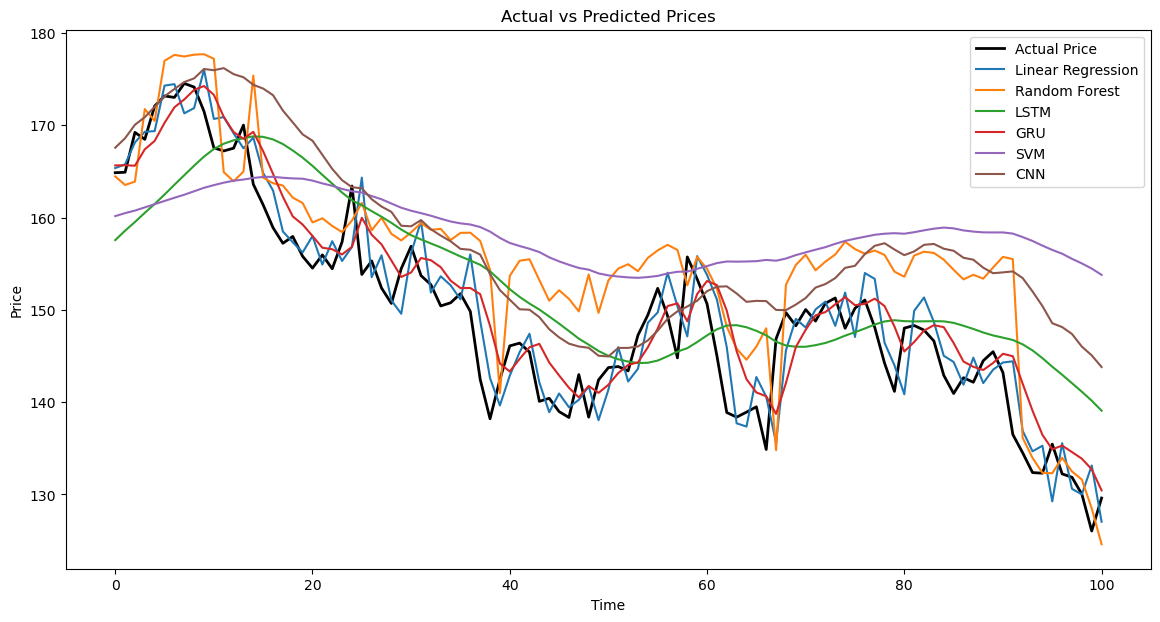

                Model  Train MSE  Test MSE  Train R2   Test R2  \
0                 GRU   0.000338  0.000812  0.995249  0.858028   
1                 SVM   0.002229  0.007509  0.968643 -0.312962   
2                 CNN   0.000724  0.004251  0.989819  0.256724   
3   Linear Regression   0.000189  0.000654  0.997342  0.885674   
4                LSTM   0.001112  0.002513  0.984352  0.560549   
5                 GRU   0.000338  0.000812  0.995249  0.858028   
6                 SVM   0.002229  0.007509  0.968643 -0.312962   
7                 CNN   0.000724  0.004251  0.989819  0.256724   
8   Linear Regression   0.000189  0.000654  0.997342  0.885674   
9       Random Forest   0.000035  0.002914  0.999511  0.490469   
10               LSTM   0.001112  0.002513  0.984352  0.560549   

    Train Adjusted R2  Test Adjusted R2  
0            0.994462               NaN  
1            0.963451               NaN  
2            0.988133               NaN  
3            0.996902               NaN

In [89]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Assuming y_test is the actual stock prices for the test set
# Rescale predictions for plotting
def rescale_predictions(scaler, predictions):
    return scaler.inverse_transform(predictions.reshape(-1, 1))

# Rescale actual values for comparison
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Combine predictions and rescale
predictions_all = [
    rescale_predictions(scaler, test_predict_lr),
    rescale_predictions(scaler, test_predict_rf),
    rescale_predictions(scaler, test_predict_lstm),
    rescale_predictions(scaler, test_predict_gru),
    rescale_predictions(scaler, test_predict_svm),
    rescale_predictions(scaler, test_predict_cnn)
]

model_names = ['Linear Regression', 'Random Forest', 'LSTM', 'GRU', 'SVM', 'CNN']

# Plotting all models in a single graph
def plot_actual_vs_predicted_all(actual, predicted, model_names, title='Actual vs Predicted Prices'):
    plt.figure(figsize=(14, 7))
    plt.plot(actual, color='black', label='Actual Price', linewidth=2)
    for i in range(len(predicted)):
        plt.plot(predicted[i], label=model_names[i])
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Plot actual vs predicted prices
plot_actual_vs_predicted_all(y_test_rescaled, predictions_all, model_names)

# Displaying the results DataFrame with accuracy measures
print(results)


## Prediction values

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
            Linear Regression  Random Forest        LSTM         GRU  \
Date                                                                   
2024-07-11         127.042626     124.604099  139.074081  130.438721   
2024-07-12         127.107617     123.806899  138.383942  130.531342   
2024-07-15         130.475644     124.004699  137.929199  130.974442   
2024-07-16         131.304426     124.077999  137.647537  131.482086  

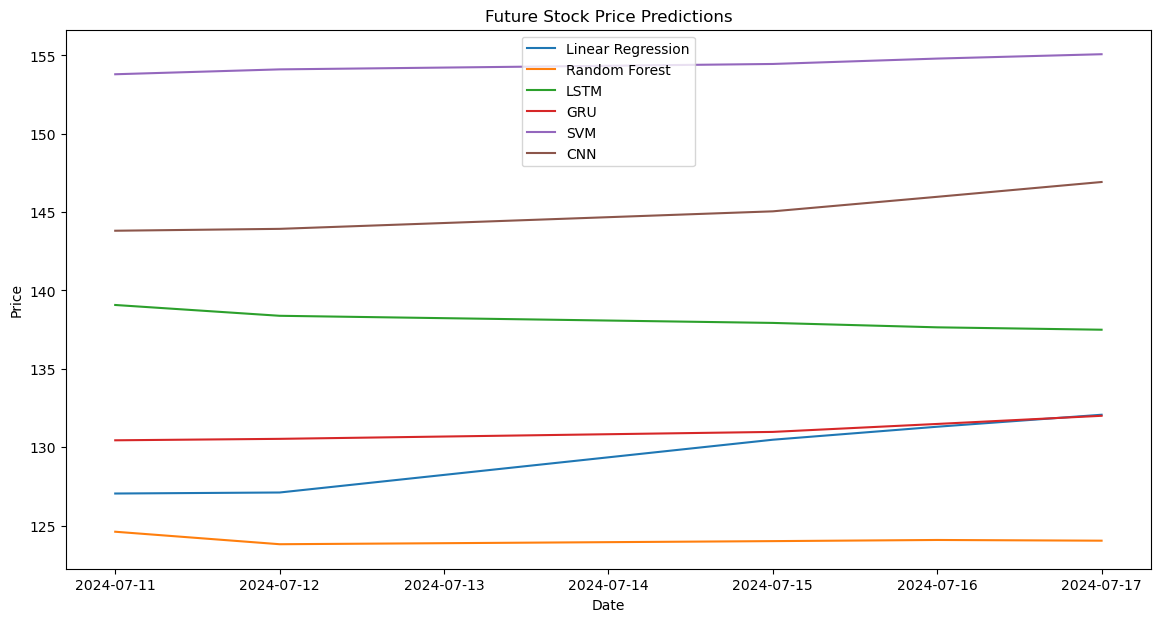

In [102]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Function to rescale predictions for plotting
def rescale_predictions(scaler, predictions):
    return scaler.inverse_transform(predictions.reshape(-1, 1))

# Function to make future predictions
def predict_future(model, data, days, model_type='sklearn'):
    future_predictions = []
    current_data = data.copy()

    for _ in range(days):
        if model_type == 'sklearn':
            next_pred = model.predict(current_data.reshape(1, -1))[0]
        elif model_type == 'lstm' or model_type == 'gru' or model_type == 'cnn':
            current_data_reshaped = current_data.reshape(1, current_data.shape[0], 1) # Adjust this as per the input shape your model expects
            next_pred = model.predict(current_data_reshaped)[0, 0]
        future_predictions.append(next_pred)

        # Update current_data to include the new prediction
        current_data = np.append(current_data[1:], next_pred)

    return np.array(future_predictions)

# Example: Assume X_test is the last window of your test set used for making future predictions
last_window = X_test[-1]

# Making 5 days predictions for each model
future_days = 5
predictions_lr = predict_future(model_lr, last_window, future_days, model_type='sklearn')
predictions_rf = predict_future(model_rf, last_window, future_days, model_type='sklearn')
predictions_lstm = predict_future(model_lstm, last_window, future_days, model_type='lstm')
predictions_gru = predict_future(model_gru, last_window, future_days, model_type='gru')
predictions_svm = predict_future(model_svm, last_window, future_days, model_type='sklearn')
predictions_cnn = predict_future(model_cnn, last_window, future_days, model_type='cnn')

# Rescale predictions back to original scale
predictions_lr_rescaled = rescale_predictions(scaler, predictions_lr)
predictions_rf_rescaled = rescale_predictions(scaler, predictions_rf)
predictions_lstm_rescaled = rescale_predictions(scaler, predictions_lstm)
predictions_gru_rescaled = rescale_predictions(scaler, predictions_gru)
predictions_svm_rescaled = rescale_predictions(scaler, predictions_svm)
predictions_cnn_rescaled = rescale_predictions(scaler, predictions_cnn)

# Generate future dates based on the last date in your test set
# Replace this with your actual method of getting the last date in your test set
last_date = pd.Timestamp('2024-07-10')  # Replace with your actual last date in y_test or based on your context
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days, freq='B')

# Create a DataFrame to store the results
predictions_df = pd.DataFrame({
    'Date': future_dates,
    'Linear Regression': predictions_lr_rescaled.flatten(),
    'Random Forest': predictions_rf_rescaled.flatten(),
    'LSTM': predictions_lstm_rescaled.flatten(),
    'GRU': predictions_gru_rescaled.flatten(),
    'SVM': predictions_svm_rescaled.flatten(),
    'CNN': predictions_cnn_rescaled.flatten()
})

predictions_df.set_index('Date', inplace=True)

# Print the future predictions
print(predictions_df)

# Plotting the future predictions
def plot_future_predictions(predictions_df, title='Future Stock Price Predictions'):
    plt.figure(figsize=(14, 7))
    for column in predictions_df.columns:
        plt.plot(predictions_df.index, predictions_df[column], label=column)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Plot future predictions
plot_future_predictions(predictions_df)
